In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"car_data.csv"

file_path = os.path.join(base_path,file_name)

df = pd.read_csv(file_path)
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


# 중고차 가격 예측 데이터셋(Vehicle dataset)
- 중고차의 여러 특징(연식, 주행거리, 연료 타입, 판매자 유형 등)을 바탕으로 중고차 판매 가격(Selling_Price)을 예측하는 회귀(Regression) 모델 구축을 위한 데이터셋입니다

## 2. 컬럼 상세
| 컬럼명 | 데이터 타입 | 의미 및 설명 |
| :--- | :--- | :--- |
| **Car_Name** | String (Object) | 차량 모델 이름 (예: ritz, sx4, ciaz, wagon r, swift, city, brio 등) |
| **Year** | Integer (int64) | 차량 출고 연도 / 연식 (예: 2014, 2017 등) |
| **Selling_Price (타겟)** | Float (float64) | 중고차 현재 판매 가격 (단위: Lakh - 10만 루피) |
| **Present_Price** | Float (float64) | 차량의 신차 출고 당시 가격 (단위: Lakh - 10만 루피) |
| **Kms_Driven** | Integer (int64) | 누적 주행거리 (단위: km) |
| **Fuel_Type** | String (Categorical) | 사용 연료 종류 (Petrol: 가솔린, Diesel: 디젤, CNG: 압축천연가스) |
| **Seller_Type** | String (Categorical) | 판매자 유형 (Dealer: 딜러 매매, Individual: 개인 직거래) |
| **Transmission** | String (Categorical) | 변속기 방식 (Manual: 수동변속기, Automatic: 자동변속기) |
| **Owner** | Integer (int64) | 이전 소유자 수 / 명의 변경 횟수 (0: 첫 번째 소유자, 1: 1회 변경 등) |

[중고차 가격 예측 데이터셋 공식 링크](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?utm_source=gemini)

In [3]:
len(df["Car_Name"].unique())

98

In [4]:
len(df)

301

In [5]:
car_df = df.drop("Car_Name", axis=1)
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1단계. 데이터 전처리

In [6]:
# 수치형: Year, Selling_Price, Present_Price, Kms_Driven, Owner
# 분류형: Fuel_Type, Seller_Type, Transmission
car_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    str    
 5   Seller_Type    301 non-null    str    
 6   Transmission   301 non-null    str    
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 18.9 KB


In [7]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


<Axes: ylabel='Kms_Driven'>

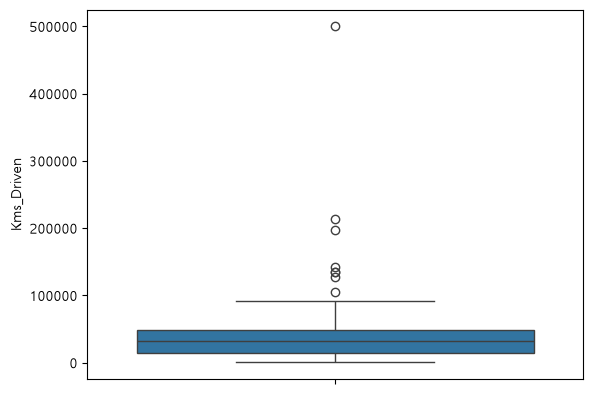

In [8]:
sns.boxplot(car_df["Kms_Driven"])

In [9]:
car_df = car_df[car_df["Kms_Driven"] <= 100000].copy().reset_index(drop=True)
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
289,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
290,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
291,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


<Axes: ylabel='Kms_Driven'>

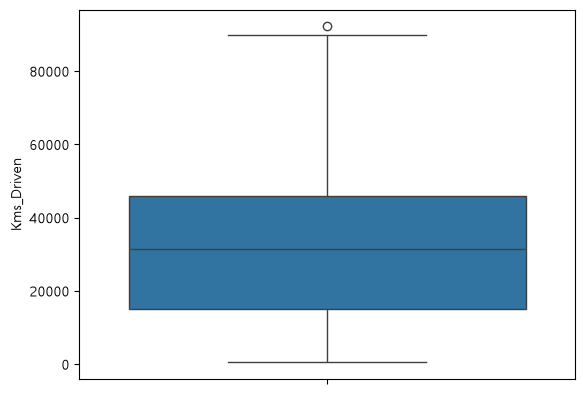

In [10]:
sns.boxplot(car_df["Kms_Driven"])

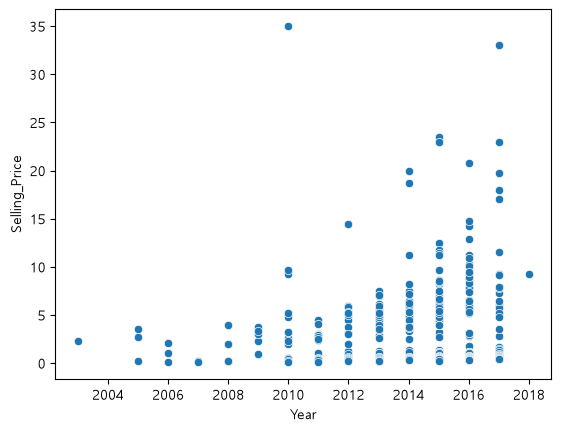

In [11]:
sns.scatterplot(car_df, x="Year", y="Selling_Price")
plt.show()

In [12]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,293.000000,293.000000,293.000000,293.000000,293.000000
mean,2013.791809,4.654710,7.445597,32652.122867,0.034130
std,2.690865,5.048855,8.462679,21435.638086,0.181873
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2015.000000,3.750000,6.100000,31427.000000,0.000000
75%,2016.000000,6.000000,9.540000,45780.000000,0.000000
max,2018.000000,35.000000,92.600000,92233.000000,1.000000


In [13]:
# 2020년 기준으로 차량의 나이가 얼마나 되었는지 알려주는 파생변수 만들기
car_df["Vehicle_Age"] = 2020 - car_df["Year"]
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6
...,...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,4
289,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,5
290,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,11
291,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,3


In [14]:
car_df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    234
Diesel     57
CNG         2
Name: count, dtype: int64

In [15]:
car_df = car_df[car_df["Fuel_Type"] != "CNG"].copy()
car_df["Fuel_Type"].value_counts()

Fuel_Type
Petrol    234
Diesel     57
Name: count, dtype: int64

In [16]:
# 분류형 데이터 -> 수치형 데이터 바꾸기(원 핫 인코딩)
car_df = pd.get_dummies(car_df, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True, dtype=int)

In [17]:
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,6,1,0,1
1,2013,4.75,9.54,43000,0,7,0,0,1
2,2017,7.25,9.85,6900,0,3,1,0,1
3,2011,2.85,4.15,5200,0,9,1,0,1
4,2014,4.60,6.87,42450,0,6,0,0,1
...,...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,0,4,0,0,1
289,2015,4.00,5.90,60000,0,5,1,0,1
290,2009,3.35,11.00,87934,0,11,1,0,1
291,2017,11.50,12.50,9000,0,3,0,0,1


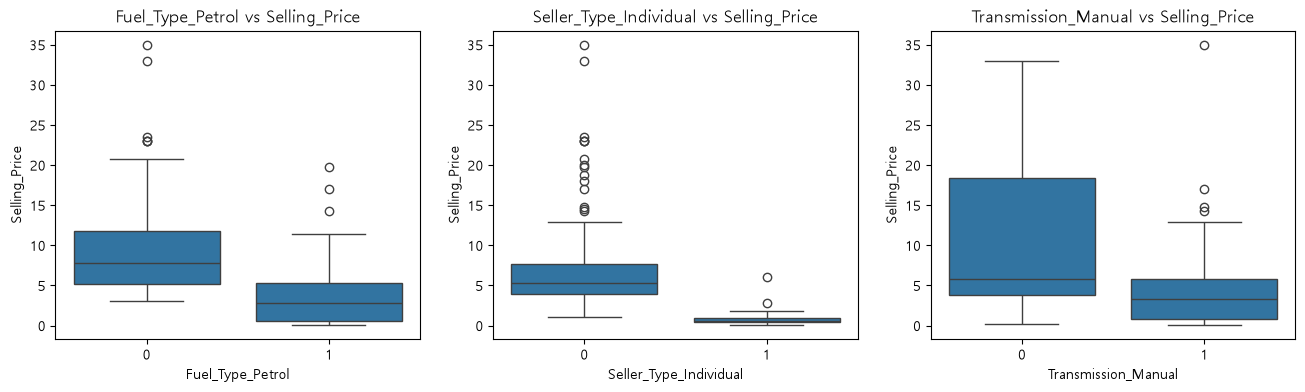

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.boxplot(ax=axes[0], data=car_df, x="Fuel_Type_Petrol", y="Selling_Price")
axes[0].set_title("Fuel_Type_Petrol vs Selling_Price")

sns.boxplot(ax=axes[1], data=car_df, x="Seller_Type_Individual", y="Selling_Price")
axes[1].set_title("Seller_Type_Individual vs Selling_Price")

sns.boxplot(ax=axes[2], data=car_df, x="Transmission_Manual", y="Selling_Price")
axes[2].set_title("Transmission_Manual vs Selling_Price")

plt.show()

In [19]:
correlation_matrix = car_df.corr()
correlation_matrix

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Year,1.000000,0.232067,-0.029342,-0.591753,-0.126058,-1.000000,-0.075838,-0.014822,-0.075008
Selling_Price,0.232067,1.000000,0.886872,0.123906,-0.100571,-0.232067,-0.541859,-0.568572,-0.372861
Present_Price,-0.029342,0.886872,1.000000,0.346668,-0.092067,0.029342,-0.459072,-0.542996,-0.316527
Kms_Driven,-0.591753,0.123906,0.346668,1.000000,-0.011859,0.591753,-0.293944,-0.355938,0.017111
Owner,-0.126058,-0.100571,-0.092067,-0.011859,1.000000,0.126058,0.045573,0.100228,0.069753
Vehicle_Age,-1.000000,-0.232067,0.029342,0.591753,0.126058,1.000000,0.075838,0.014822,0.075008
Fuel_Type_Petrol,-0.075838,-0.541859,-0.459072,-0.293944,0.045573,0.075838,1.000000,0.359843,0.083699
Seller_Type_Individual,-0.014822,-0.568572,-0.542996,-0.355938,0.100228,0.014822,0.359843,1.000000,0.092048
Transmission_Manual,-0.075008,-0.372861,-0.316527,0.017111,0.069753,0.075008,0.083699,0.092048,1.000000


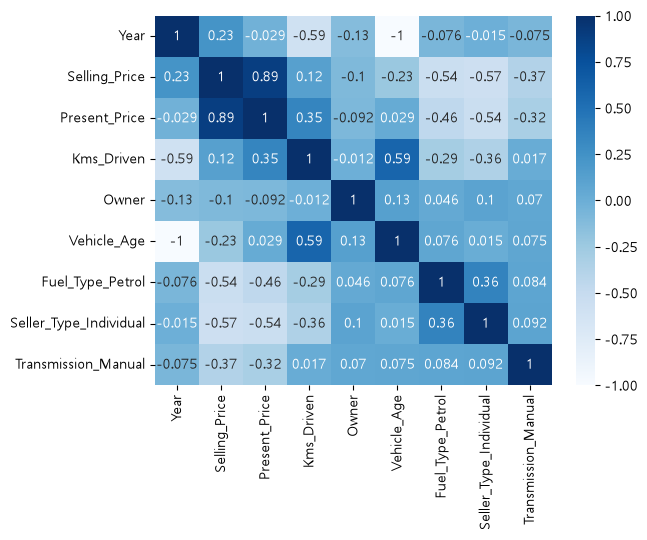

In [20]:
sns.heatmap(correlation_matrix, cmap="Blues", annot=True)
plt.show()

In [21]:
X = car_df.drop("Selling_Price", axis=1)
y = car_df["Selling_Price"]

In [22]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

# 다중공선성 발생 -> 오류

C:\Users\User\AppData\Local\Temp\ipykernel_18956\2124495450.py:1: UserWarning: The design matrix is poorly conditioned (condition number=1.97e+14). VIF calculations may be numerically unstable.
  vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


[np.float64(1000799917193443.5),
 np.float64(1.8376967654809044),
 np.float64(2.1977433217464752),
 np.float64(1.0359296837214012),
 np.float64(1000799917193443.5),
 np.float64(1.4057367043061255),
 np.float64(1.5780749638588998),
 np.float64(1.1453843968860409)]

In [23]:
car_df.drop("Year",axis=1, inplace=True)

In [24]:
X = car_df.drop("Selling_Price", axis=1)
y = car_df["Selling_Price"]

In [25]:
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

# 다중공선성 발생한 컬럼 제거되었으므로 오류 X

[np.float64(1.837735697200037),
 np.float64(2.1977428836146764),
 np.float64(1.0359295875648606),
 np.float64(1.8531241130257092),
 np.float64(1.4057465858950131),
 np.float64(1.578113226142904),
 np.float64(1.1453885376660138)]

## 트리
   - 계층적으로 자료를 표현할 때 적합한 자료구조
   - 데이터를 순차적으로 저장하지 않기 때문에 비선형 자료구조
   - 트리 내에 또 다른 트리가 있는 재귀적 자료구조
   - 하나의 루트 노드와 0개 이상의 하위 트리로 작성됨

### 트리의 사용 예시
   - 계층적 데이터 저장: 파일 및 폴더
   - 효율적인 검색속도: 효율적인 삽입, 삭제, 검색을 위해 사용
   - 데이터 베이스 인덱싱 구현
   - 힙(Heap)

### 트리 용어 정리 
   - 루트(Root)노드 : 트리의 가장 높은 곳에 있는 노드
   - 모든 노드는 루트노드의 서브트리에 속한다
   - 리프(Leaf)노드 : 트리의 가장 하단에 있는 노드
   - 자식노드가 없는 노드
   - 자식(Child)노드 : 동일한 부모를 가진 노드들을 의미함
   - 리프노드가 아닌 자식이 있는 노드 = 내부(Internal)노드, 비 단말(Non-Terminal)노드
   - 형제(Sibling)노드 : 동일한 부모를 가진 노드들을 의미한다
   - 조상(ancestro)노드 :  루트까지 경로상에 있는 모든 노드들의 집합
   - 후손(Descendant)노드 : 노드 아래로 매달린 모든 노드들의 집합
   - 서브트리(Subtree)노드 : 노드 자신과 후손 노드로 구성된 트리
   - 차수(Degree) : 어떤 노드가 가지고 있는 자식의 수
   - 레벨(Level) : 루트에서 얼마나 멀리 떨어져 있는지를 나타내는 것
   - 키(Key) : 탐색에 사용되는 노드에 저장된 정보

<img src="https://i.namu.wiki/i/8pViDtKiYxEmcz1zj2WHZEpLHeu4q4n1bAjOOTvA4rLde3d-miR4lbCeFRjhzuTV1SLW5vFdg81Q6vb6fm1I9Q.webp" style="width:800px;"/>

## 결정 트리(Decision Tree)란?
- 결정 트리는 데이터에 숨겨져 있는 규칙을 컴퓨터가 스스로 찾아내어, 마치 스무고개(IF-ELSE) 게임처럼 나무 가지를 뻗으며 정답을 찾아가는 지도학습(Supervised Learning) 알고리즘입니다.
- 한 줄 결론, 구간의 평균값으로 그 값을 예측하게 만든다.

| 구분 | 결정 트리 분류 (Classifier) | 결정 트리 회귀 (Regressor) |
| :--- | :--- | :--- |
| 목적 | 데이터가 어떤 그룹/카테고리에 속하는지 분류 | 데이터의 연속된 실숫값(수치)을 예측 |
| 예시 | 이 손님이 가방을 `산다(1)` / `안 산다(0)` | 오늘 특정 시간대에 따릉이가 `몇 대` 대여될까? |
| 최종 정답 결정 방식 | 다수결의 원칙<br>(마지막 방에 더 많은 쪽으로 분류) | 평균값 계산<br>(마지막 방에 모인 수치들의 평균을 내어 예측) |

### 2. 작동 원리 (데이터가 분리되는 과정)
1. 뿌리 노드 (Root Node): 전체 데이터가 시작되는 지점입니다.
2. 중간 노드 (Internal Node): 컴퓨터가 불순도를 낮추기 위해 최적의 질문(예: `Hour <= 17`)을 던져 데이터를 두 갈래로 쪼갭니다.
3. 최종 노드 (Leaf Node): 더 이상 쪼개지지 않는 마지막 나뭇잎 방입니다. 
   * 분류: 이 방에 모인 데이터 중 가장 많은 클래스가 최종 정답이 됩니다.
   * 회귀: 이 방에 모인 데이터들의 평균값이 최종 예측 숫자가 됩니다.

### 3. 장점과 단점
* 장점:
  * 시각화했을 때 컴퓨터가 왜 이런 판단을 내렸는지 사람이 눈으로 로직을 완벽히 이해할 수 있습니다. (설명 가능성 높음)
  * 데이터의 스케일링(정규화) 같은 전처리 작업의 영향을 거의 받지 않아 편리합니다.
* 단점:
  * 조건을 무한정 만들게 놔두면 훈련 데이터에만 완벽하게 맞아떨어지는 과적합(Overfitting)에 매우 취약합니다.
  * 해결책: 나무의 최대 깊이를 제한하는 가지치기(pruning) `max_depth` 같은 하이퍼파라미터 조율이 필수적입니다.

### 결정 트리 수행 순서
1. 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행
2. 만약 분류라면
   - Gini 불순도(Gini Impurity)
   - 엔트로피(Entropy)

4. 만약 회귀라면
   - 평균 제곱 오차(Mean Squared Error, MSE)
   - 절대 평균 오차(Mean Absolute Error

5. 각 하위 노드에 대해 위 단계를 반복하고 이 과정으로 여러 깊이로 설정합니다
6. 모든 노드가 더이상 나눌 수 없거나 특정 조건을 만족할 떄까지 반복합니다
7. 더 이상 분할이 불가능할 때 리프 노트가 생성됩니다
   - 분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
   - 회귀 문제: 평균값을 예측값으로 사용

#### Gini 불순도(Gini Impurity)
- 한 노드에 데이터 순수도(Purity)를 측정하는 지표입니다. 한 노드에 있는 샘플들이 동일한 클래스에 속할 확률이 높을수록 Gini 불순도가 낮아집니다
- 즉 노드가 얼마나 섞여있는지 나타내는 지표입니다.

#### 엔트로피(Entropy)
- 정보의 불확실성(혼란도)를 측정합니다. 엔트로피가 높을 수록 해당 노드에 데이터가 더 섞여있으며 예측하기 어렵습니다.
- 데이터가 균등하게 분포될 때 최대값을 가집니다.

### 예시 데이터프레임 (온도, 습도, 운동량)
- 아래 데이터가 있다고 가정해보자.

| 샘플 번호 | 온도 (°C) | 습도 (%) | 운동량 (Target, 분) |
| :---: | :---: | :---: | :---: |
| #1 | 15 | 40 | **60** |
| #2 | 18 | 45 | **55** |
| #3 | 28 | 75 | **20** |
| #4 | 30 | 80 | **15** |
| #5 | 32 | 85 | **10** |

### 1. 분산을 구한다
* **대상 데이터 (운동량):** `[60, 55, 20, 15, 10]` (총 5개)
* **평균 ($\mu$):** $(60 + 55 + 20 + 15 + 10) / 5 = \mathbf{32}$
* **분산 ($\sigma^2$):** 각 데이터에서 평균(32)을 뺀 뒤 제곱한 값들의 평균
  $$((60-32)^2 + (55-32)^2 + (20-32)^2 + (15-32)^2 + (10-32)^2) / 5$$
  $$= (784 + 529 + 144 + 289 + 484) / 5 = \mathbf{446}$$

- **처음 상태:** 운동량의 평균은 **32**, 분산(오차 위험도)은 **446**인 상태에서 출발합니다.

### 2. 운동량 평균 32에 해당하는 기준으로 중간 값후보에 등록한다.
예를 들어 습도를 골랐다면
* **#2 샘플:** 45%
* **#3 샘플:** 75%
- 45%와 75%의 딱 중간인 **60%** `(45 + 75) / 2` 가 칼날 후보가 된다.

- 왼쪽 그룹: 60보다 작은 그룹(40, 45)
- 오른쪽 그룹: 60보다 큰 그룹(75, 80, 85)

### 3. 왼쪽 그룹과 오른쪽 그룹 각각의 분산을 구한다
#### 1) 왼쪽 그룹 (습도 60% 미만: 40%, 45%)
* **대상 운동량:** `[60, 55]`
* **평균:** $(60 + 55) / 2 = \mathbf{57.5}$
* **분산 식:**
  $$\text{왼쪽 분산} = \frac{(60 - 57.5)^2 + (55 - 57.5)^2}{2}$$
  $$\text{왼쪽 분산} = \frac{(2.5)^2 + (-2.5)^2}{2} = \frac{6.25 + 6.25}{2} = \mathbf{6.25}$$

#### 2) 오른쪽 그룹 (습도 60% 이상: 75%, 80%, 85%)
* **대상 운동량:** `[20, 15, 10]`
* **평균:** $(20 + 15 + 10) / 3 = \mathbf{15}$
* **분산 식:**
  $$\text{오른쪽 분산} = \frac{(20 - 15)^2 + (15 - 15)^2 + (10 - 15)^2}{3}$$
  $$\text{오른쪽 분산} = \frac{(5)^2 + (0)^2 + (-5)^2}{3} = \frac{25 + 0 + 25}{3} = \frac{50}{3} \approx \mathbf{16.67}$$

* **가중 분산 합 공식:**
  $$\text{자식 노드 분산 합} = \left( \frac{\text{왼쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{왼쪽 분산} \right) + \left( \frac{\text{오른쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{오른쪽 분산} \right)$$

* **실제 계산 식:**
  $$\text{자식 노드 분산 합} = \left( \frac{2}{5} \times 6.25 \right) + \left( \frac{3}{5} \times 16.67 \right)$$
  $$\text{자식 노드 분산 합} = 2.5 + 10 = \mathbf{12.5}$$

### 4. 최종 분산 감소량을 구한다

이제 처음에 구했던 부모 노드의 분산(446)에서 방금 구한 자식들의 분산 합(12.5)을 빼서 이 칼날(습도 60%)의 최종 점수를 매깁니다.

$$\text{분산 감소량} = \text{부모 분산} - \text{자식 분산 합}$$
$$\text{분산 감소량} = 446 - 12.5 = \mathbf{433.5}$$

### 5. 모든 컬럼의 값들을 계산하고 최종 분산 감소량이 가장 큰 값들만 선택하여 데이터가 1개가 될 때까지 나눈다.

In [26]:
# 수치형 데이터가 y(정답)일 때에는 층하추출할 수 없음
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(232, 7) (59, 7) (232,) (59,)


In [27]:
car_df

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,1,0,1
1,4.75,9.54,43000,0,7,0,0,1
2,7.25,9.85,6900,0,3,1,0,1
3,2.85,4.15,5200,0,9,1,0,1
4,4.60,6.87,42450,0,6,0,0,1
...,...,...,...,...,...,...,...,...
288,9.50,11.60,33988,0,4,0,0,1
289,4.00,5.90,60000,0,5,1,0,1
290,3.35,11.00,87934,0,11,1,0,1
291,11.50,12.50,9000,0,3,0,0,1


In [28]:
scaler = StandardScaler()

In [29]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [30]:
from sklearn.tree import DecisionTreeRegressor

In [31]:
dtr = DecisionTreeRegressor(random_state=2026)

In [32]:
dtr.fit(X_train_scaled, y_train)

DecisionTreeRegressor(random_state=2026)

In [33]:
y_pred1 = dtr.predict(X_test_scaled)

In [34]:
print(y_pred1)

[ 5.25  6.25  1.1   5.25  1.15  0.3   0.45  4.5   4.75  2.65  7.45  0.25
  0.3   3.95  5.4   6.95  2.    6.6   8.4   0.12  6.4   0.5  11.25  2.55
  0.75  0.75  6.4   5.5   0.4   0.65  0.15  4.75  0.48  8.25  1.15  2.65
  5.9   1.95  4.75  5.4   0.5   4.15  4.15  5.3   5.4   0.16  0.78  3.9
 12.9   1.1   2.7   5.5   0.78  4.75  4.95  0.38  0.6   8.4   4.75]


In [35]:
# 주의사항
# 회귀는 예측문제이므로(0과1로 나누어지는 방식이 아니므로) 예측값과 실제값이 일치하는지 아닌지 정확도를 평가할 수 없다.
# dtr.score(X_test, y_pred1)

### 회귀문제의 모델 평가
| 지표 | 수식 | 특징 | 장점 | 단점 |
| :---: | :---: | :--- | :--- | :--- |
| **MAE** | $\frac{1}{n}\sum\|y - \hat{y}\|$ | 절대값 오차의 평균 | 직관적이며, **이상치(Outlier)에 강인**함 | 느린 최적화, 미분이 불가능한 지점 존재 |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | 제곱 오차의 평균 | 미분이 매끄러워 **가장 많이 사용**됨 | 오차가 클수록 제곱되어 **이상치에 민감**함 |
| **RMSE** | $\sqrt{\text{MSE}}$ | 제곱 오차 평균의 제곱근 | **원래 데이터와 단위가 일치**하여 직관적임 | 결국 MSE 기반이라 이상치의 영향을 받음 |

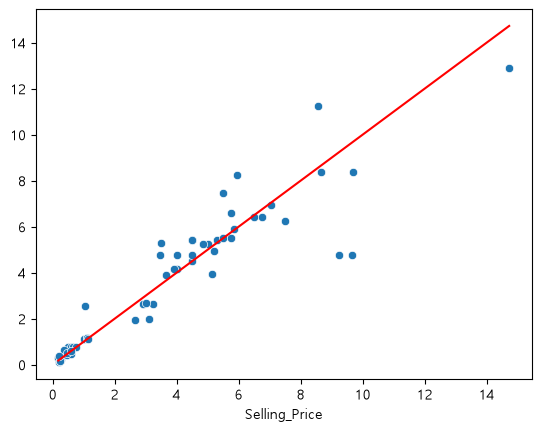

In [36]:
sns.scatterplot(x=y_test, y=y_pred1)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color="red")

In [37]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error

In [38]:
rmse = root_mean_squared_error(y_test, y_pred1)
print(f"RMSE: {rmse}")
# 예측값에서 벗어난 평균적인 잔차가 약 1.17

RMSE: 1.1793764511636315


### 선형 모델

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lr = LinearRegression()

In [41]:
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [42]:
y_pred2 = lr.predict(X_test_scaled)
y_pred2

array([ 4.61187633,  8.87616827, -0.4125723 ,  6.79632359,  1.20000392,
       -0.32403003, -0.78849016,  4.85194644,  3.91652607,  2.11196057,
        6.22941616,  0.05574463,  0.04460138,  5.56217552,  4.66784867,
        8.99113058,  2.67999757,  6.08049545,  8.00988568, -2.35503289,
        5.73815521, -0.56987319,  8.74363881, -0.27201414,  0.99398381,
        0.99638655,  7.67288602,  6.04677594,  1.66079481,  0.09603984,
       -1.2412441 ,  4.75903806,  0.49783695,  5.69713079,  1.52192145,
        4.71409725,  7.73263558,  3.44667454,  3.21421233,  5.59496688,
        0.24534036,  3.23924562,  5.07973979,  4.49185226,  4.9399641 ,
        0.69910229,  1.66990431,  4.36153492, 11.18418196,  0.81684943,
        3.14608675,  6.6945395 ,  1.55728179, 10.71672671,  5.82731871,
       -2.25803925,  1.08698662,  8.11913886, 11.04144744])

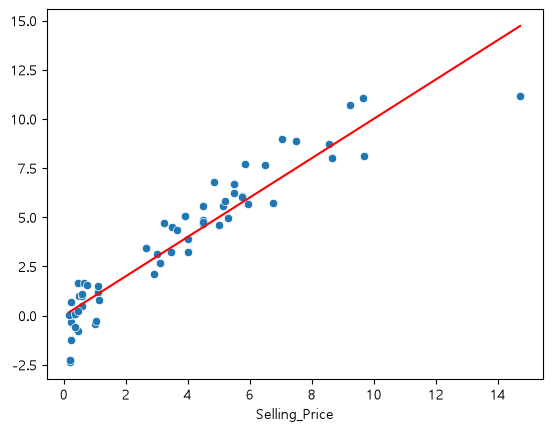

In [43]:
sns.scatterplot(x=y_test, y=y_pred2)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color="red")
plt.show()

In [44]:
# ※ rmse 중요 ※ 회귀 문제를 푸는 건지 분류 문제를 푸는 건지에 따라 다름
rmse2 = root_mean_squared_error(y_test, y_pred2)
print(f"결정트리 RMSE: {rmse}")
print(f"선형모델 RMSE: {rmse2}")

결정트리 RMSE: 1.1793764511636315
선형모델 RMSE: 1.107305330556363


In [45]:
# 규제
# 결정트리의 최대 깊이와 맨 마지막 leaf들의 최소 갯수 설정(하이퍼파라미터)
dtr = DecisionTreeRegressor(max_depth=60, min_samples_leaf=40)

In [46]:
dtr.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=60, min_samples_leaf=40)

In [47]:
y_pred3 = dtr.predict(X_test_scaled)

In [48]:
rmse3 = root_mean_squared_error(y_test, y_pred3)

print(f"규제 적용(가지치기) RMSE: {rmse3}")

규제 적용(가지치기) RMSE: 2.0986541062585546


In [49]:
from sklearn.tree import plot_tree

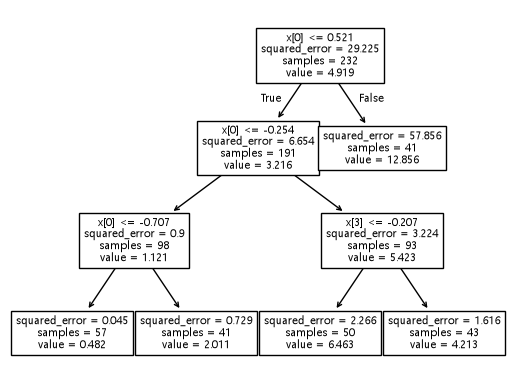

In [50]:
plot_tree(dtr)
plt.show()

# 랜덤 포레스트(RandomForestRegressor)
- "나무(결정 트리) 한 개는 과적합되기 쉬우니, 서로 다른 나무 100개를 만들어 그들의 예측값을 평균 내자!"
- 즉 결정트리의 상위 버전

## 핵심 하이퍼파라미터
* `n_estimators`: 숲에 심을 **나무의 개수** (기본값 100개, 많을수록 좋지만 무거워짐)
* `max_depth`, `min_samples_split` 등: 기존 결정 트리의 규제 파라미터와 완전히 동일하게 나무 각각에 적용됨

In [51]:
from sklearn.ensemble import RandomForestRegressor

In [52]:
rf = RandomForestRegressor(random_state=2026)

In [53]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=2026)

In [55]:
y_pred4 = rf.predict(X_test)
y_pred4

array([ 5.5522,  7.1021,  1.0805,  5.1795,  1.1605,  0.2946,  0.4953,
        4.6759,  4.381 ,  2.732 ,  6.968 ,  0.2897,  0.3552,  4.296 ,
        4.9265,  7.207 ,  2.908 ,  5.663 ,  9.0031,  0.1736,  6.505 ,
        0.5199, 11.1725,  2.313 ,  0.5913,  0.6123,  6.634 ,  4.919 ,
        0.4353,  0.4311,  0.2163,  5.322 ,  0.5643,  7.5596,  1.1895,
        2.5485,  6.705 ,  2.9305,  4.4495,  4.559 ,  0.5311,  4.2535,
        4.189 ,  4.8015,  5.0235,  0.2126,  0.6848,  4.1155, 11.7961,
        1.126 ,  2.6565,  5.6325,  0.6596,  8.1269,  4.9935,  0.3646,
        0.6241,  9.5421,  8.1124])

In [56]:
rf.score(X_test, y_test)

0.9425783974564237

In [65]:
rmse = root_mean_squared_error(y_pred4, y_test)
print(f"랜덤 포레스트 RMSE: {rmse}")

랜덤 포레스트 RMSE: 0.7542029215994546


In [66]:
rf.feature_importances_

array([9.02040292e-01, 1.86576343e-02, 1.46096196e-05, 6.89513300e-02,
       3.29817532e-03, 4.00198947e-03, 3.03596946e-03])

In [69]:
features_imp = pd.DataFrame({
    "Features": X_train.columns,
    "importances": rf.feature_importances_
}).sort_values(by="importances", ascending=False)
features_imp

,Features,importances
0,Present_Price,0.902040
3,Vehicle_Age,0.068951
1,Kms_Driven,0.018658
5,Seller_Type_Individual,0.004002
4,Fuel_Type_Petrol,0.003298
6,Transmission_Manual,0.003036
2,Owner,0.000015


Text(0.5, 1.0, '특성 중요도')

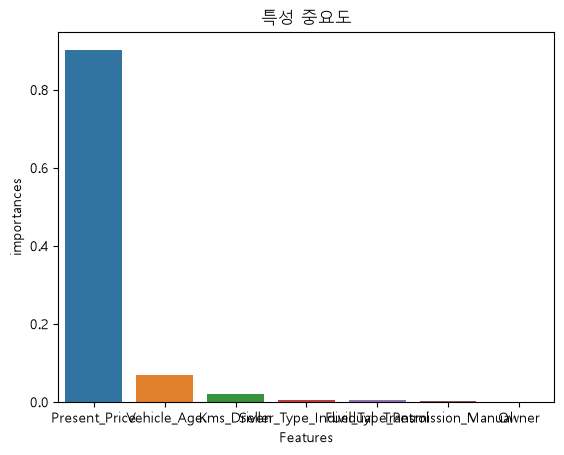

In [71]:
sns.barplot(features_imp, x="Features", y="importances", hue="Features")
plt.title("특성 중요도")